In [ ]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# General data information

In [3]:
con = duckdb.connect()
df = con.execute(f"select * from '../data/interactions_final.parquet'").df()

In [5]:
df.head(2)

,user_id,parent_asin,rating,last_timestamp,n_reviews,helpful_vote_total,verified_purchase,title,author,price,main_category,item_avg_rating,item_rating_count,store,split
0,AFZL2GTKPEOGFIWLXANM6JQVSXRQ,1683690125,3.0,2018-07-31 20:01:59.606,1,1.0,0,We Sold Our Souls: A Novel,{'avatar': 'https://m.media-amazon.com/images/...,24.99,Books,4.3,2179,Grady Hendrix (Author),train
1,AFZL2GTKPEOGFIWLXANM6JQVSXRQ,1328948935,4.0,2018-05-07 03:32:18.893,1,1.0,0,Brightly Burning,{'avatar': 'https://m.media-amazon.com/images/...,12.93,Books,4.3,519,Alexa Donne (Author),train


In [8]:
print(f'shape: {df.shape}')
print(f'first date - {min(df['last_timestamp'])}, last date - {max(df['last_timestamp'])}')

shape: (3527385, 15)
first date - 2018-01-01 00:00:00.623000, last date - 2023-09-06 17:08:23.504000


Data source: [Amazon Reviews 2023 Books](https://amazon-reviews-2023.github.io/main.html)

Dateset size: **3,5M interactions** user-item

Time period: **5,5 years** (from 01.01.2018 to 06.09.2023)

### Columns:
**IDs**:
- user_id - unique user ID
- parent_asin - unique book ID

**User-Book interaction:**
- rating - average rating of the book given by the user 
- last_timestamp - date of user's last review to the book
- n_reviews - number of reviews the user has given to the book
- helpful_vote_total - summirized number of votes that the user's review to the book was helpful 
- verified_purchase - flag that indicates that the purchase was verified by Amazon

**Book infromation:**
- title	
- author	
- price	
- main_category	
- item_avg_rating - average rating of the book in general
- item_rating_count	- number of ratings of the book in general
- store	- book brand or publisher

**Split** - train/val/test group

# Splits 

In [ ]:
split_stats = con.execute("""
    select split,
        count(*)/3527385*100 as percentage,
        count(*) as n_interactions,
        count(distinct user_id) as n_users,
        count(distinct parent_asin) as n_items,
    from '../data/interactions_final.parquet'
    group by split
    order by percentage desc
""").df()
print(split_stats)

   split  percentage  n_interactions  n_users  n_items
0  train   91.581327         3230426   692133   308122
1    val    5.497812          193929   106180    79878
2   test    2.920861          103030    62319    54173


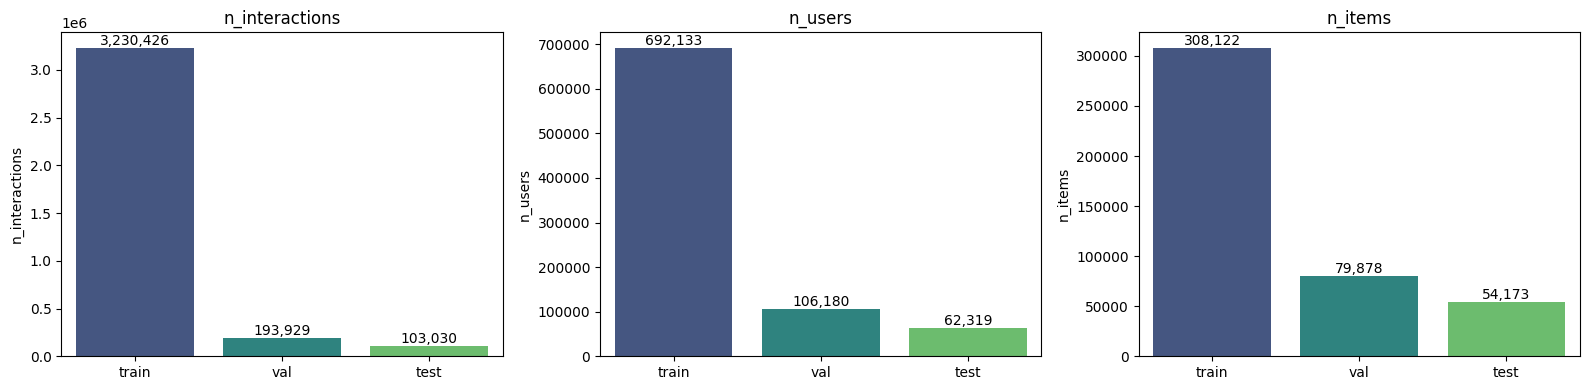

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["n_interactions", "n_users", "n_items"]):
    sns.barplot(data=split_stats, x="split", y=col, ax=ax, palette="viridis")
    ax.set_title(col)
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom", fontsize=10)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

# Activity and popularity

## User activity

In [ ]:
user_activity = con.execute(f"""
    select user_id, 
    count(*) as n_interactions
    from '../data/interactions_final.parquet'
    where split = 'train'
    group by user_id
""").df()

In [27]:
user_d = user_activity["n_interactions"].describe(percentiles=[0.5, 0.9, 0.99])
print(user_d)

count    692133.000000
mean          4.667349
std           9.448087
min           1.000000
50%           3.000000
90%           8.000000
99%          35.000000
max        1331.000000
Name: n_interactions, dtype: float64


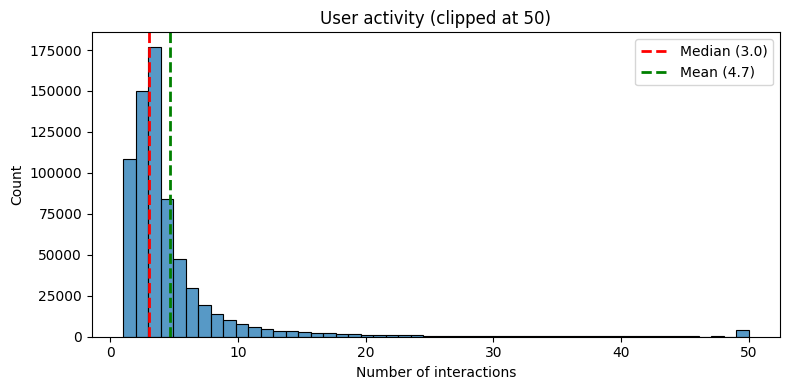

In [46]:
plt.figure(figsize=(8, 4))
sns.histplot(user_activity["n_interactions"].clip(upper=50), bins=50)
plt.axvline(user_d['50%'], linewidth=2, linestyle='--', color='red', label=f'Median ({user_d['50%']})')
plt.axvline(user_d['mean'], linewidth=2, linestyle='--', color='green', label=f'Mean ({user_d['mean']:.1f})')
plt.title("User activity (clipped at 50)")
plt.xlabel("Number of interactions")
plt.legend()
plt.tight_layout()
plt.show()

most users have low activity - right skewed distribution

## Book popularity

In [ ]:
book_pop = con.execute(f"""
    select parent_asin, 
    count(distinct user_id) as n_users
    from '../data/interactions_final.parquet'
    where split = 'train'
    group by parent_asin
    order by n_users desc
""").df()

In [20]:
book_pop["n_users"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count    308122.000000
mean         10.484243
std          34.840259
min           1.000000
50%           5.000000
90%          19.000000
95%          33.000000
99%         100.000000
max        3954.000000
Name: n_users, dtype: float64

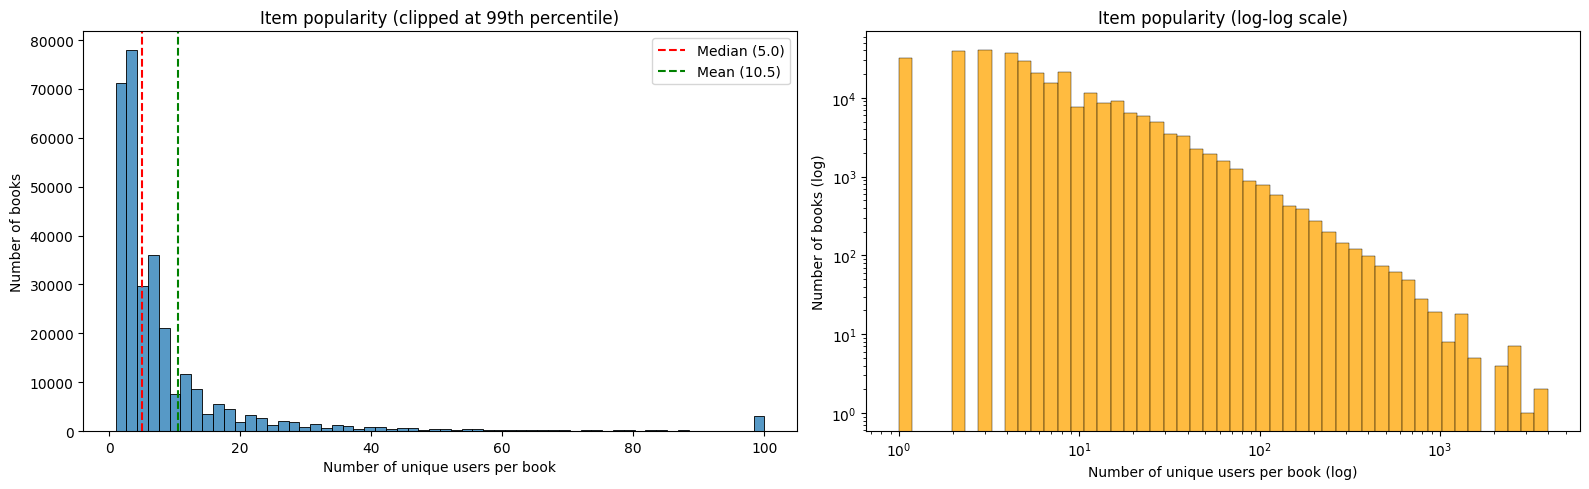

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

clip_val = int(book_pop["n_users"].quantile(0.99))
sns.histplot(book_pop["n_users"].clip(upper=clip_val), bins=60, ax=axes[0])
axes[0].axvline(book_pop["n_users"].median(), color="red", linestyle="--", label=f"Median ({book_pop['n_users'].median():.1f})")
axes[0].axvline(book_pop["n_users"].mean(), color="green", linestyle="--", label=f"Mean ({book_pop['n_users'].mean():.1f})")
axes[0].set_xlabel("Number of unique users per book")
axes[0].set_ylabel("Number of books")
axes[0].set_title(f"Item popularity (clipped at 99th percentile)")
axes[0].legend()

sns.histplot(book_pop["n_users"], bins=np.logspace(0, np.log10(book_pop["n_users"].max()), 50), ax=axes[1],
    color="orange", edgecolor="black", linewidth=0.3)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Number of unique users per book (log)")
axes[1].set_ylabel("Number of books (log)")
axes[1].set_title("Item popularity (log-log scale)")

plt.tight_layout()
plt.show()

In [58]:
print(f"top15 books cover {book_pop['n_users'].head(10).sum() / book_pop['n_users'].sum() * 100:.1f}% of interactions")

top15 books cover 0.9% of interactions


on average a book has 10.5 unique users (but with large variance). also right skewed distribution with long tail (50% of books have <= 5 readers). there are no blockbusters and user have diverse taste in books

In [56]:
top15_books = book_pop.head(15).merge(pd.read_parquet("data/meta_books_filtered.parquet")[["parent_asin", "title", "author"]],
    on="parent_asin", how="left")

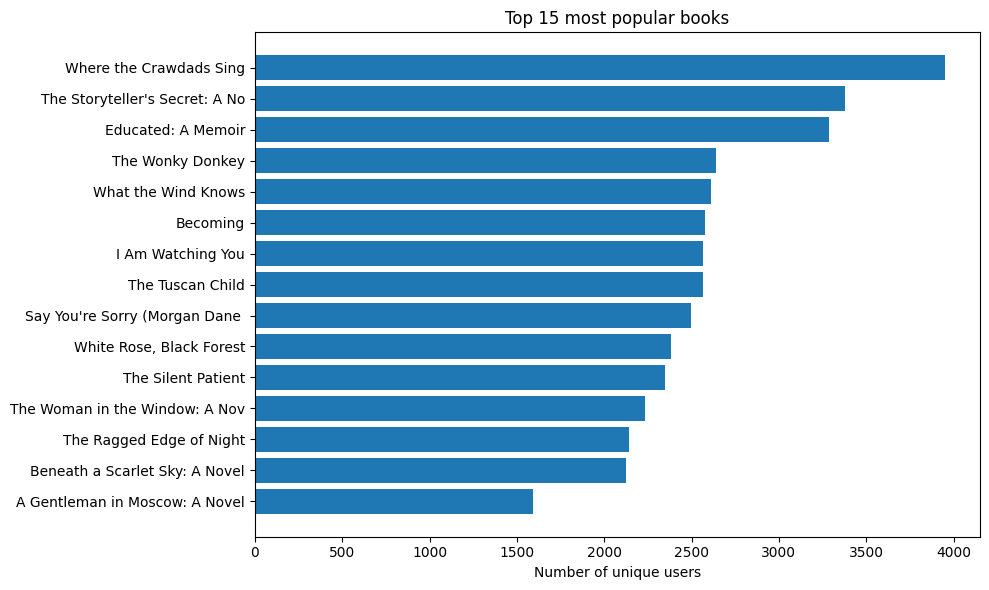

In [57]:
plt.figure(figsize=(10,6))
plt.barh(range(len(top15_books)), top15_books["n_users"])
plt.yticks(range(len(top15_books)), [t[:30] if isinstance(t, str) else str(t) for t in top15_books["title"]], fontsize=10)
plt.gca().invert_yaxis()
plt.xlabel("Number of unique users")
plt.title("Top 15 most popular books")
plt.tight_layout()
plt.show()